Querying and temporarily downloading lightcurves for TIC 332887363
Temporary download directory: /var/folders/qp/235bwt15061gvt4r31cy2m4r0000gn/T/tess_tmp_x1zm0lrm

Showing raw light curves for each downloaded file:


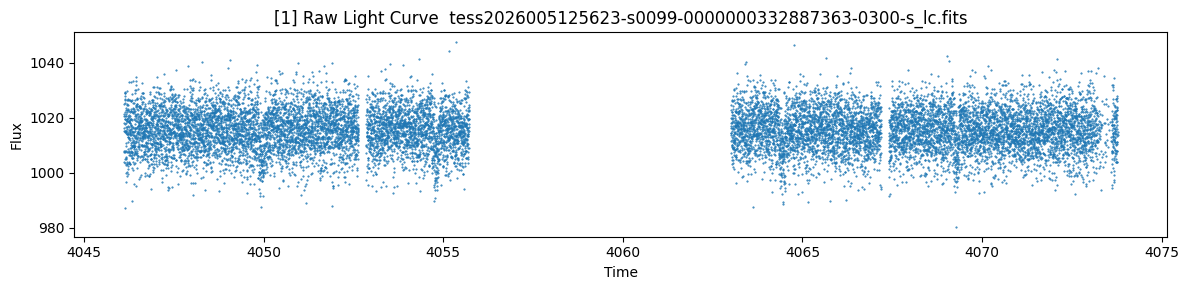

[1] tess2026005125623-s0099-0000000332887363-0300-s_lc.fits  time range: 4046.112 - 4073.777  points: 14078


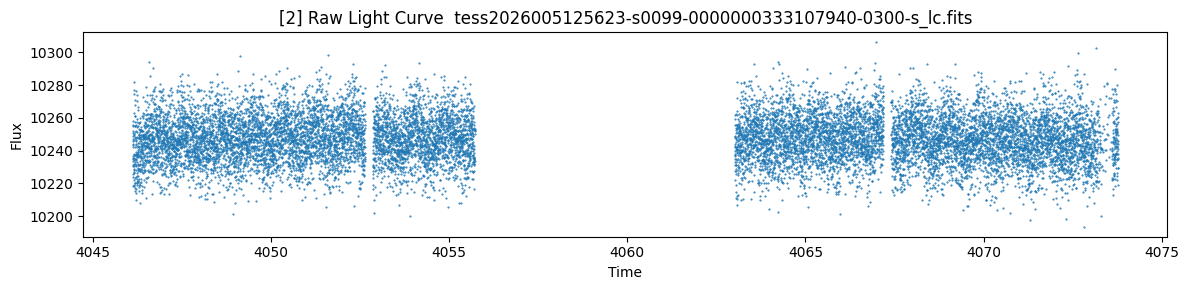

[2] tess2026005125623-s0099-0000000333107940-0300-s_lc.fits  time range: 4046.112 - 4073.777  points: 14078


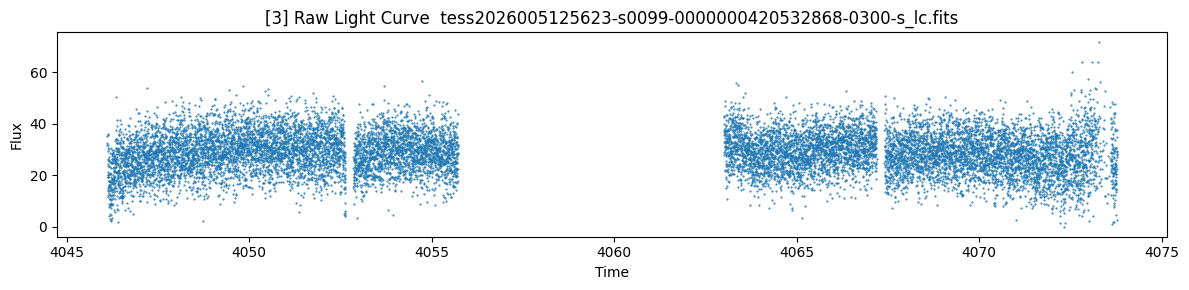

[3] tess2026005125623-s0099-0000000420532868-0300-s_lc.fits  time range: 4046.112 - 4073.777  points: 14078


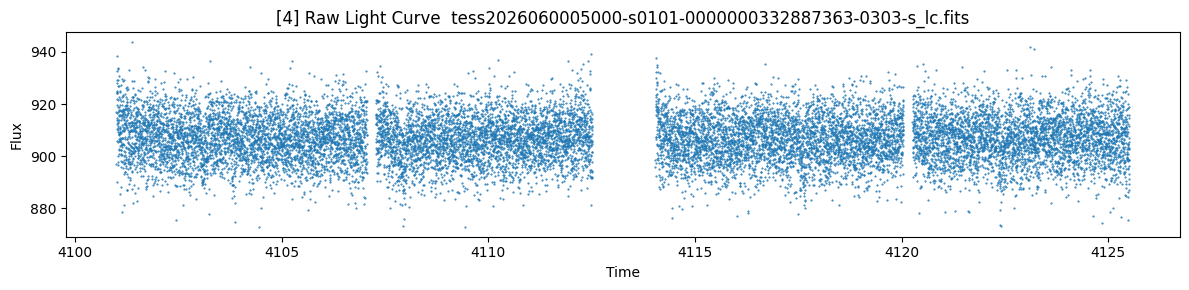

[4] tess2026060005000-s0101-0000000332887363-0303-s_lc.fits  time range: 4100.996 - 4125.514  points: 16237


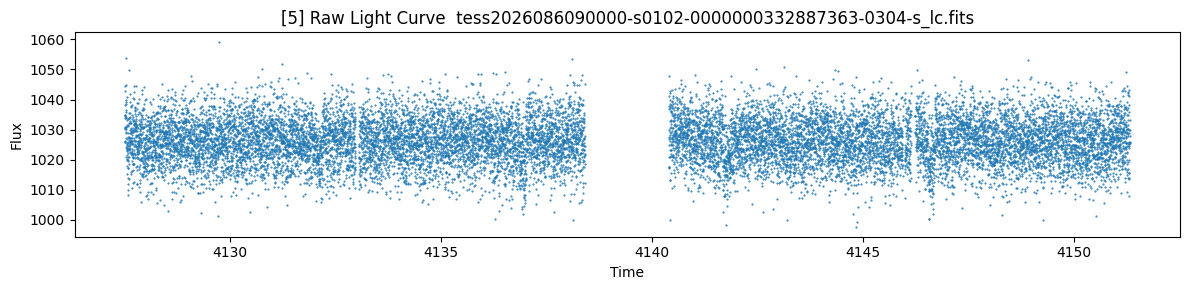

[5] tess2026086090000-s0102-0000000332887363-0304-s_lc.fits  time range: 4127.515 - 4151.314  points: 15496


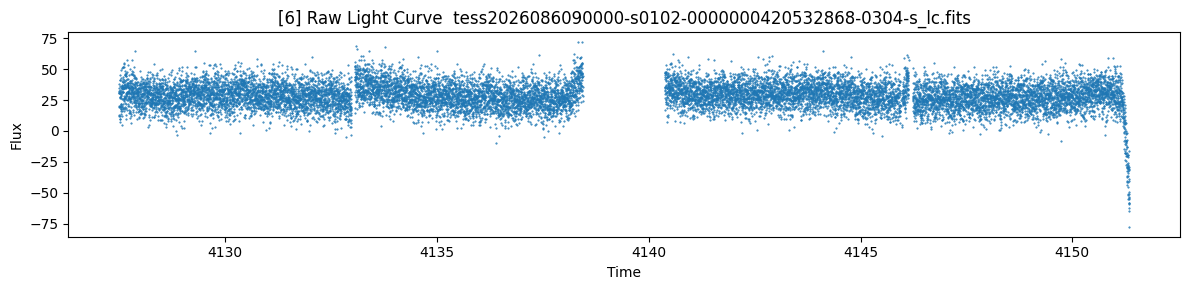

[6] tess2026086090000-s0102-0000000420532868-0304-s_lc.fits  time range: 4127.489 - 4151.348  points: 15579

Downloaded files:
[1] tess2026005125623-s0099-0000000332887363-0300-s_lc.fits
[2] tess2026005125623-s0099-0000000333107940-0300-s_lc.fits
[3] tess2026005125623-s0099-0000000420532868-0300-s_lc.fits
[4] tess2026060005000-s0101-0000000332887363-0303-s_lc.fits
[5] tess2026086090000-s0102-0000000332887363-0304-s_lc.fits
[6] tess2026086090000-s0102-0000000420532868-0304-s_lc.fits



Enter the number (or comma-separated numbers) of the file(s) to analyze in detail (e.g. 1 or 1,3):  4



Analyzing: tess2026060005000-s0101-0000000332887363-0303-s_lc.fits


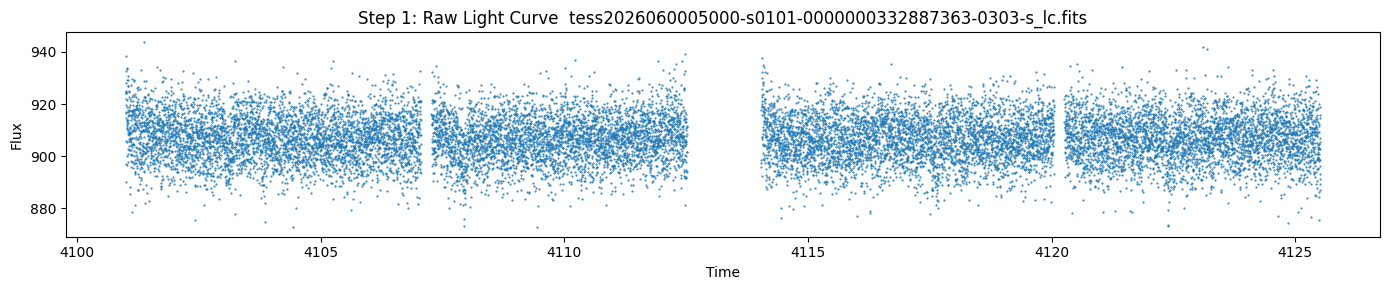

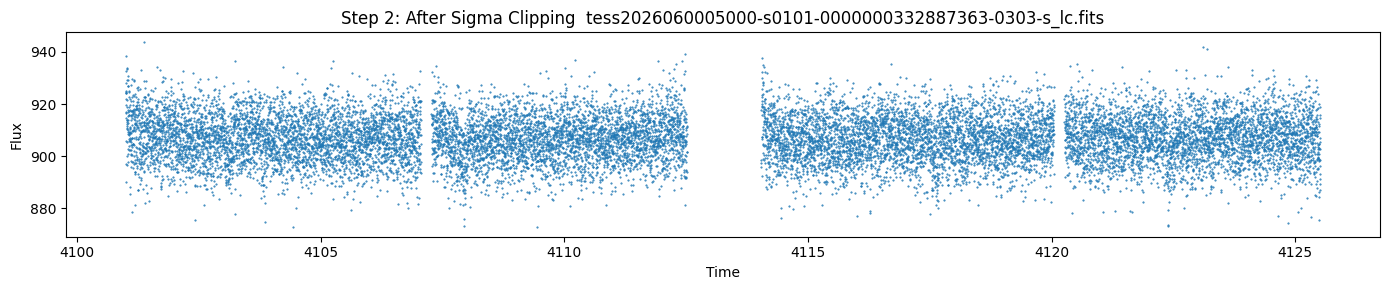

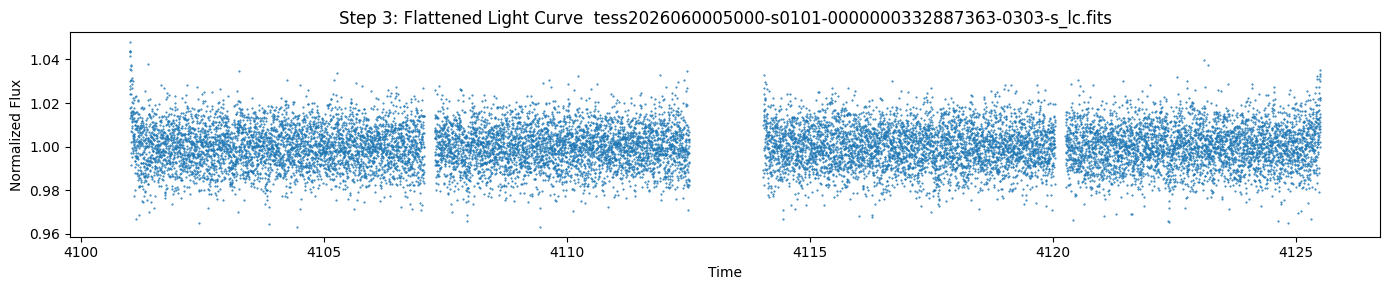

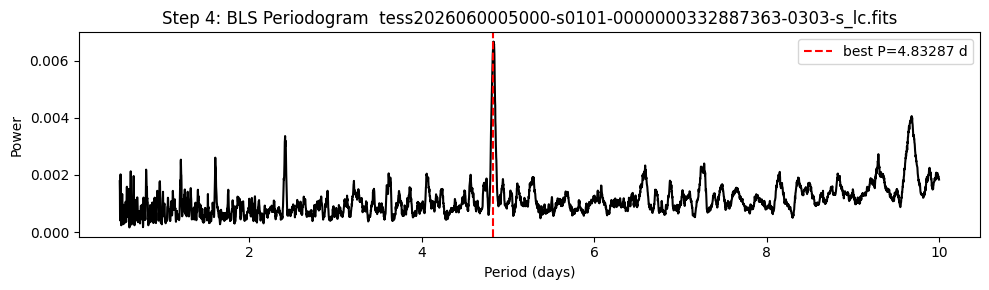

  -> Best P=4.832867 d, power=0.0067, duration=0.1600 d


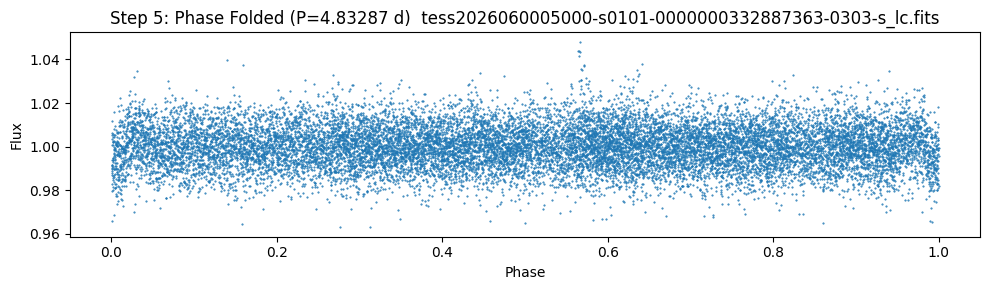

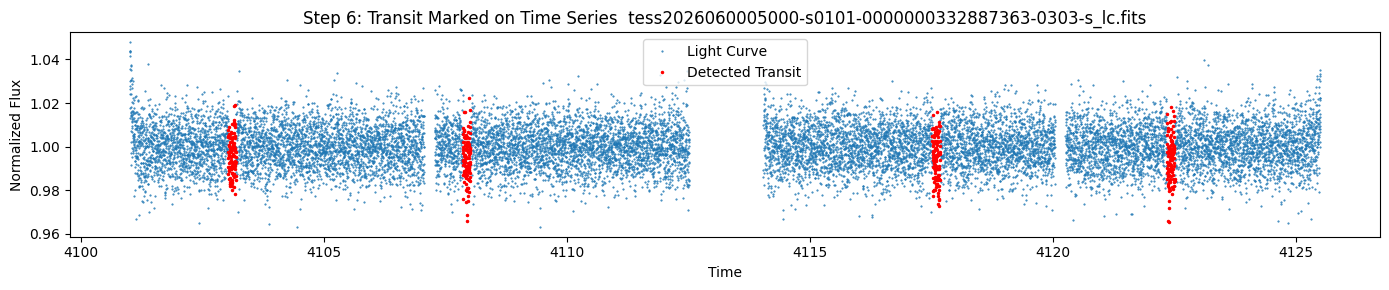


Summary of analyzed files:
  file: tess2026060005000-s0101-0000000332887363-0303-s_lc.fits  period=4.832867 d  power=0.0067 dur=0.1600 d
Temporary files removed: /var/folders/qp/235bwt15061gvt4r31cy2m4r0000gn/T/tess_tmp_x1zm0lrm


In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Interactive TESS per-file BLS explorer

流程：
 1) 查询并临时下载指定 TIC 的所有 LIGHTCURVE 产品到临时目录（下载后会删除）
 2) 依次显示每个文件的原始光变曲线（Step 1），并在终端列出编号 1..N
 3) 用户在终端输入要分析的编号（或多个编号，用逗号分隔）
 4) 对用户选定的文件逐个执行并展示 Step 1..Step 6（和你原来程序一致）
 5) 处理完毕后删除临时文件并退出

注意：
 - 需要安装：astroquery astropy numpy scipy matplotlib
 - 在无 GUI 环境（如纯终端服务器）运行时，matplotlib 可能无法弹窗；建议在本地或 Jupyter 中运行
"""

import os
import tempfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
from astroquery.mast import Observations
from astropy.io import fits
from astropy.stats import sigma_clip
from astropy.timeseries import BoxLeastSquares
from scipy.signal import medfilt

# -------------------------
# 用户参数（可修改）
# -------------------------
TIC = 332887363
PERIOD_MIN = 0.5
PERIOD_MAX = 10.0
N_PERIODS = 5000
DURATIONS = np.linspace(0.05, 0.3, 10)
MEDFILT_KERNEL = 301   # must be odd; will adapt if too large
SIGMA_CLIP_SIGMA = 5
SIGMA_CLIP_ITERS = 3

# -------------------------
# 辅助：查询并下载 lightcurve 到临时目录
# -------------------------
def download_lightcurves_temp(tic):
    obs = Observations.query_criteria(
        objectname=f"TIC {tic}",
        dataproduct_type="timeseries",
        obs_collection="TESS"
    )
    if len(obs) == 0:
        raise RuntimeError(f"No observations found for TIC {tic}")

    products = Observations.get_product_list(obs)
    # 尝试筛选 LIGHTCURVE
    lc_candidates = Observations.filter_products(products, productSubGroupDescription=["LIGHTCURVE", "LC"])
    if len(lc_candidates) == 0:
        # 退而求其次按文件名匹配
        mask = [("lc.fits" in fn.lower() or "_s_lc.fits" in fn.lower()) for fn in products['productFilename']]
        if any(mask):
            lc_candidates = products[mask]
        else:
            raise RuntimeError("No lightcurve products found for TIC {}".format(tic))

    # 创建临时目录
    tmpdir = tempfile.mkdtemp(prefix="tess_tmp_")
    print("Temporary download directory:", tmpdir)
    manifest = Observations.download_products(lc_candidates, download_dir=tmpdir)
    # manifest['Local Path'] 可能是 astropy Column
    local_paths = [str(x) for x in manifest['Local Path']]
    # 过滤不存在或空路径
    local_paths = [p for p in local_paths if p and os.path.exists(p)]
    if len(local_paths) == 0:
        shutil.rmtree(tmpdir)
        raise RuntimeError("No files downloaded")
    return tmpdir, local_paths

# -------------------------
# 辅助：读取 time & flux（优先 PDCSAP）
# -------------------------
def read_time_flux(local_path):
    with fits.open(local_path, memmap=False) as hdul:
        if len(hdul) < 2:
            raise RuntimeError("No table extension in " + local_path)
        data = hdul[1].data
        cols = [c.lower() for c in data.columns.names]
        if 'pdcsap_flux' in cols:
            flux = data['PDCSAP_FLUX'].astype(np.float64)
        elif 'sap_flux' in cols:
            flux = data['SAP_FLUX'].astype(np.float64)
        else:
            raise RuntimeError("No PDCSAP_FLUX or SAP_FLUX in " + local_path)
        if 'time' not in data.columns.names and 'TIME' not in data.columns.names:
            raise RuntimeError("No TIME column in " + local_path)
        time = data['TIME'].astype(np.float64)
    mask = np.isfinite(time) & np.isfinite(flux)
    time = time[mask]
    flux = flux[mask]
    order = np.argsort(time)
    return time[order], flux[order]

# -------------------------
# 显示原始图像（Step 1）用于选择
# -------------------------
def show_all_raw(local_paths):
    print("\nShowing raw light curves for each downloaded file:")
    for i, p in enumerate(local_paths, start=1):
        base = os.path.basename(p)
        try:
            time, flux = read_time_flux(p)
        except Exception as e:
            print(f"[{i}] {base}  SKIP (read error): {e}")
            continue
        plt.figure(figsize=(12,3))
        plt.plot(time, flux, '.', markersize=1)
        plt.title(f"[{i}] Raw Light Curve  {base}")
        plt.xlabel("Time")
        plt.ylabel("Flux")
        plt.tight_layout()
        plt.show()
        print(f"[{i}] {base}  time range: {time.min():.3f} - {time.max():.3f}  points: {len(time)}")

# -------------------------
# 对单个文件执行 Step1..Step6 并展示
# -------------------------
def analyze_and_plot(local_path):
    base = os.path.basename(local_path)
    print("\nAnalyzing:", base)
    time, flux = read_time_flux(local_path)

    # Step 1: Raw
    plt.figure(figsize=(14,3))
    plt.plot(time, flux, '.', markersize=1)
    plt.title(f"Step 1: Raw Light Curve  {base}")
    plt.xlabel("Time"); plt.ylabel("Flux")
    plt.tight_layout(); plt.show()

    # Step 2: Sigma clipping
    flux_clip = sigma_clip(flux, sigma=SIGMA_CLIP_SIGMA, maxiters=SIGMA_CLIP_ITERS)
    mask = ~flux_clip.mask
    time2 = time[mask]; flux2 = flux[mask]
    plt.figure(figsize=(14,3))
    plt.plot(time2, flux2, '.', markersize=1)
    plt.title(f"Step 2: After Sigma Clipping  {base}")
    plt.xlabel("Time"); plt.ylabel("Flux")
    plt.tight_layout(); plt.show()

    # Step 3: Detrend
    k = MEDFILT_KERNEL
    if k >= len(flux2):
        k = max(3, (len(flux2) // 3) // 2 * 2 + 1)
    trend = medfilt(flux2, kernel_size=k)
    if np.all(trend == 0):
        trend = np.nanmedian(flux2)
    trend[trend == 0] = np.nanmedian(trend)
    flux_flat = flux2 / trend
    plt.figure(figsize=(14,3))
    plt.plot(time2, flux_flat, '.', markersize=1)
    plt.title(f"Step 3: Flattened Light Curve  {base}")
    plt.xlabel("Time"); plt.ylabel("Normalized Flux")
    plt.tight_layout(); plt.show()

    # Step 4: BLS
    bls = BoxLeastSquares(time2, flux_flat)
    periods = np.linspace(PERIOD_MIN, PERIOD_MAX, N_PERIODS)
    result = bls.power(periods, DURATIONS)
    best_idx = np.nanargmax(result.power)
    P = result.period[best_idx]; t0 = result.transit_time[best_idx]; Tdur = result.duration[best_idx]
    best_power = result.power[best_idx]
    plt.figure(figsize=(10,3))
    plt.plot(result.period, result.power, '-k')
    plt.axvline(P, color='r', linestyle='--', label=f"best P={P:.5f} d")
    plt.title(f"Step 4: BLS Periodogram  {base}")
    plt.xlabel("Period (days)"); plt.ylabel("Power"); plt.legend()
    plt.tight_layout(); plt.show()
    print(f"  -> Best P={P:.6f} d, power={best_power:.4f}, duration={Tdur:.4f} d")

    # Step 5: Phase fold
    phase = ((time2 - t0) / P) % 1
    plt.figure(figsize=(10,3))
    plt.plot(phase, flux_flat, '.', markersize=1)
    plt.title(f"Step 5: Phase Folded (P={P:.5f} d)  {base}")
    plt.xlabel("Phase"); plt.ylabel("Flux")
    plt.tight_layout(); plt.show()

    # Step 6: Mark in-transit
    in_transit = bls.transit_mask(time2, P, Tdur, t0)
    plt.figure(figsize=(14,3))
    plt.plot(time2, flux_flat, '.', markersize=1, label="Light Curve")
    plt.plot(time2[in_transit], flux_flat[in_transit], 'r.', markersize=3, label="Detected Transit")
    plt.title(f"Step 6: Transit Marked on Time Series  {base}")
    plt.xlabel("Time"); plt.ylabel("Normalized Flux"); plt.legend()
    plt.tight_layout(); plt.show()

    return {"file": local_path, "period": float(P), "power": float(best_power), "duration": float(Tdur)}

# -------------------------
# 主流程
# -------------------------
def main():
    print("Querying and temporarily downloading lightcurves for TIC", TIC)
    tmpdir, local_paths = download_lightcurves_temp(TIC)
    try:
        # 先逐个显示原始图像并编号
        show_all_raw(local_paths)

        # 列出编号供用户选择
        print("\nDownloaded files:")
        for i, p in enumerate(local_paths, start=1):
            print(f"[{i}] {os.path.basename(p)}")

        sel = input("\nEnter the number (or comma-separated numbers) of the file(s) to analyze in detail (e.g. 1 or 1,3): ").strip()
        if sel == "":
            print("No selection made. Exiting.")
            return
        # 解析用户输入
        indices = []
        for part in sel.split(','):
            try:
                idx = int(part.strip())
                if 1 <= idx <= len(local_paths):
                    indices.append(idx-1)
                else:
                    print("Index out of range:", idx)
            except ValueError:
                print("Invalid input:", part)

        if len(indices) == 0:
            print("No valid indices selected. Exiting.")
            return

        # 对每个选定文件逐个分析并展示 Step1..Step6
        summaries = []
        for idx in indices:
            p = local_paths[idx]
            try:
                res = analyze_and_plot(p)
                summaries.append(res)
            except Exception as e:
                print("Error analyzing", p, e)

        # 打印汇总
        if len(summaries) > 0:
            print("\nSummary of analyzed files:")
            for s in summaries:
                print(f"  file: {os.path.basename(s['file'])}  period={s['period']:.6f} d  power={s['power']:.4f} dur={s['duration']:.4f} d")

    finally:
        # 清理临时目录（删除下载的文件）
        try:
            shutil.rmtree(tmpdir)
            print("Temporary files removed:", tmpdir)
        except Exception as e:
            print("Failed to remove temporary directory:", tmpdir, e)

if __name__ == '__main__':
    main()
